# 1. Setup & Data Loading

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Stats
from scipy import stats
import warnings
warnings.filterwarnings('ignore')



In [44]:
df = pd.read_csv("https://raw.githubusercontent.com/RAKIBUL424/Datasets/refs/heads/main/job_salary_prediction_dataset.csv")


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [46]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [47]:
categorical_cols = ['job_title', 'education_level', 'industry', 'company_size', 
                    'location', 'remote_work']
for col in categorical_cols:

    print(len(df[col].unique()))



12
5
10
5
10
3


# 2. Exploratory Data Analysis

In [48]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


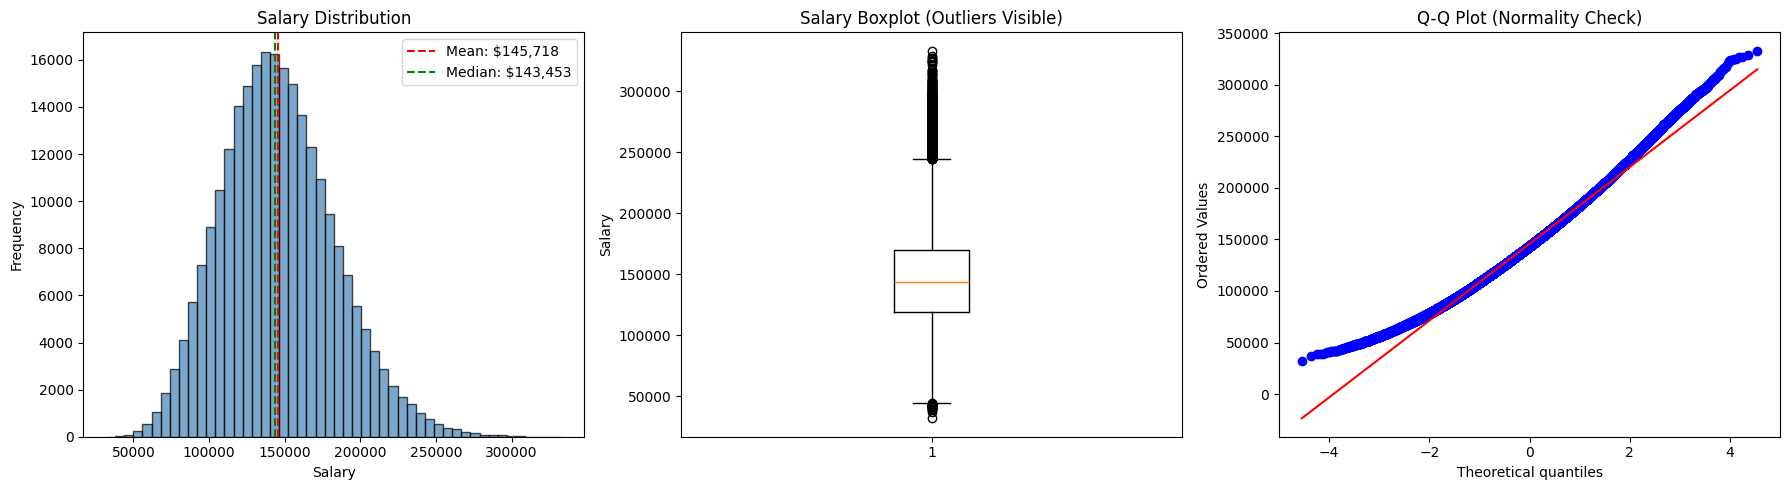

Skewness: 0.38 (Positive = right-tailed)
Kurtosis: 0.15


In [49]:
# Salary distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['salary'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['salary'].mean(), color='red', linestyle='--', label=f"Mean: ${df['salary'].mean():,.0f}")
axes[0].axvline(df['salary'].median(), color='green', linestyle='--', label=f"Median: ${df['salary'].median():,.0f}")
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Salary Distribution')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['salary'], vert=True)
axes[1].set_ylabel('Salary')
axes[1].set_title('Salary Boxplot (Outliers Visible)')

# Q-Q plot
stats.probplot(df['salary'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['salary'].skew():.2f} (Positive = right-tailed)")
print(f"Kurtosis: {df['salary'].kurtosis():.2f}")


### 2.1 Categorical Feature Analysis

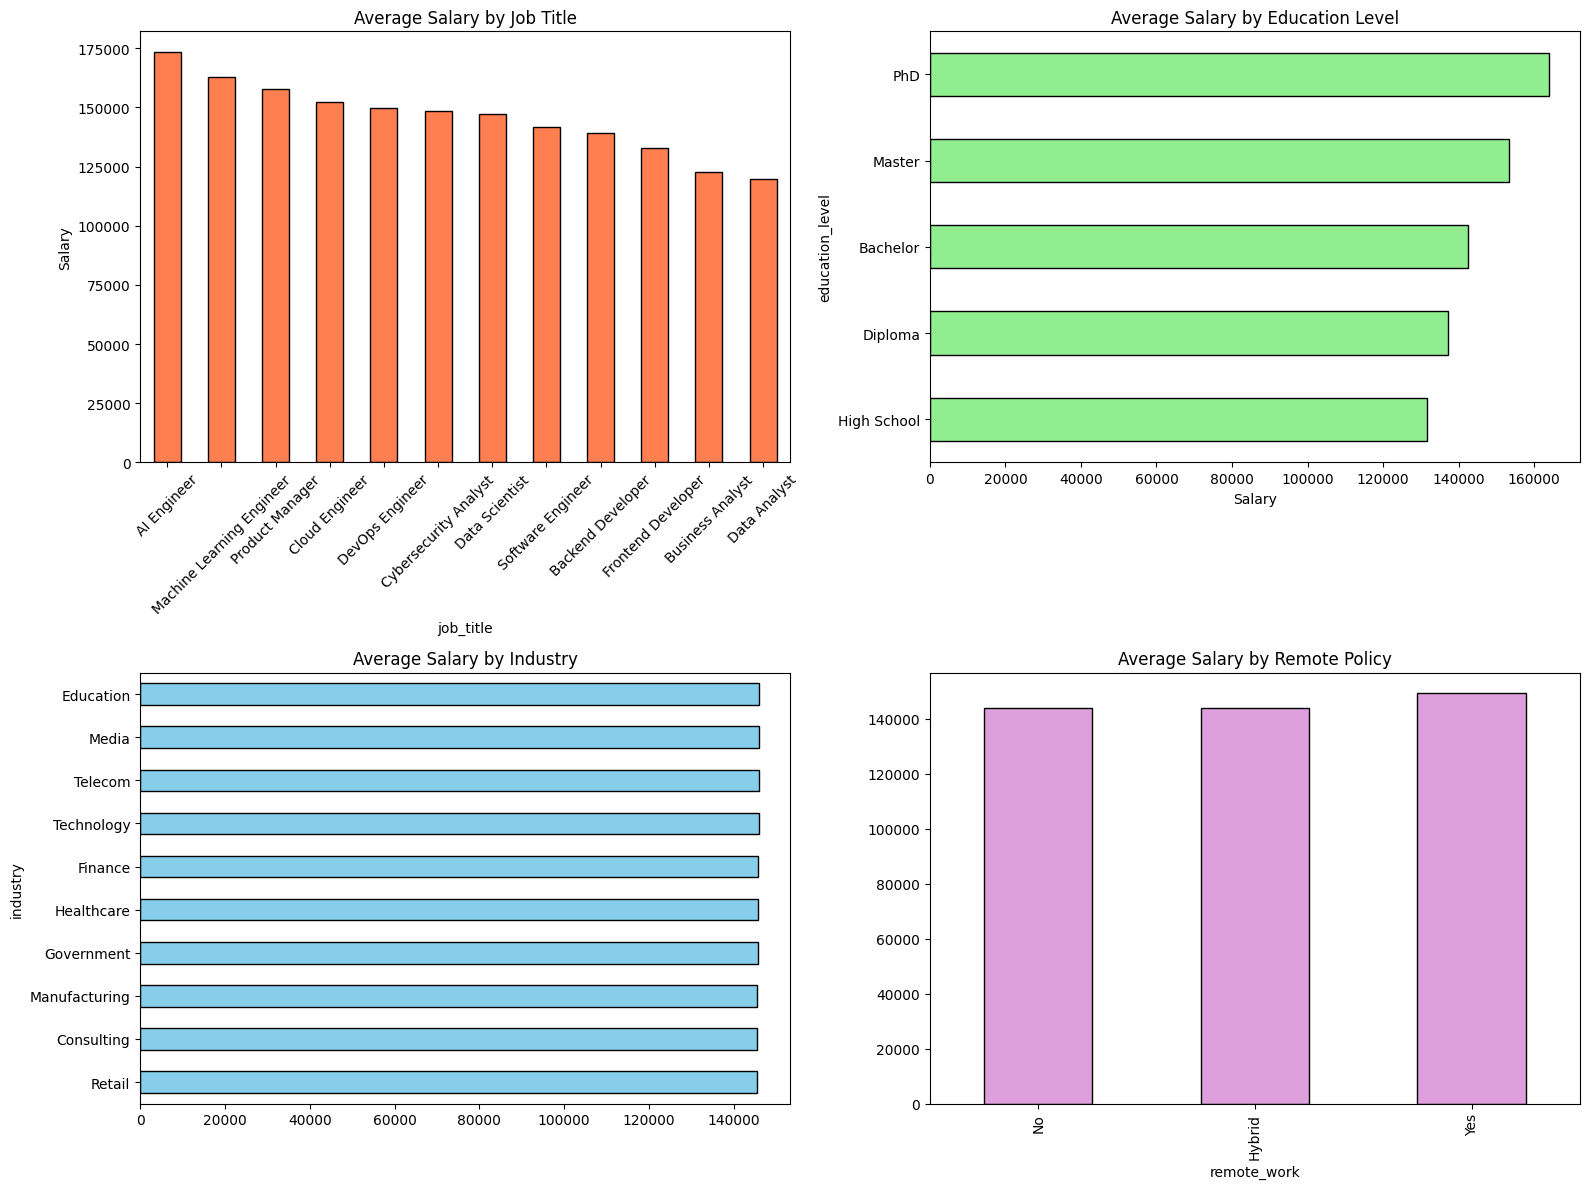

In [50]:
# Salary by job title
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Job title
job_salary = df.groupby('job_title')['salary'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)
job_salary['mean'].plot(kind='bar', ax=axes[0,0], color='coral', edgecolor='black')
axes[0,0].set_title('Average Salary by Job Title')
axes[0,0].set_ylabel('Salary')
axes[0,0].tick_params(axis='x', rotation=45)

# Education level
edu_salary = df.groupby('education_level')['salary'].mean().sort_values()
edu_salary.plot(kind='barh', ax=axes[0,1], color='lightgreen', edgecolor='black')
axes[0,1].set_title('Average Salary by Education Level')
axes[0,1].set_xlabel('Salary')

# Industry
ind_salary = df.groupby('industry')['salary'].mean().sort_values()
ind_salary.plot(kind='barh', ax=axes[1,0], color='skyblue', edgecolor='black')
axes[1,0].set_title('Average Salary by Industry')

# Remote work
remote_salary = df.groupby('remote_work')['salary'].mean().sort_values()
remote_salary.plot(kind='bar', ax=axes[1,1], color='plum', edgecolor='black')
axes[1,1].set_title('Average Salary by Remote Policy')

plt.tight_layout()
plt.show()


### 2.2 Numerical Feature Correlations

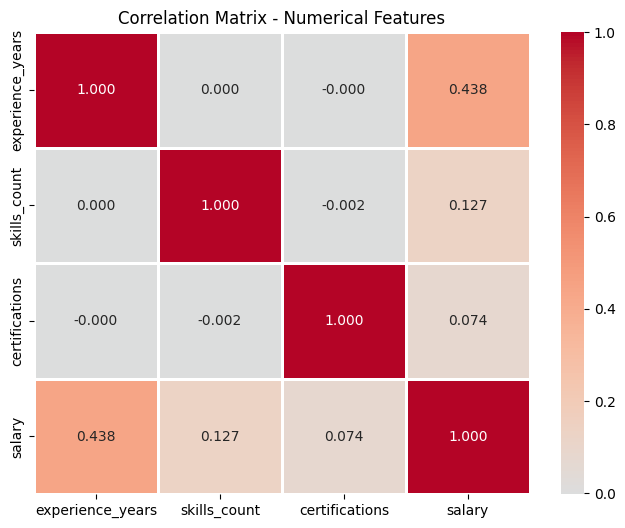

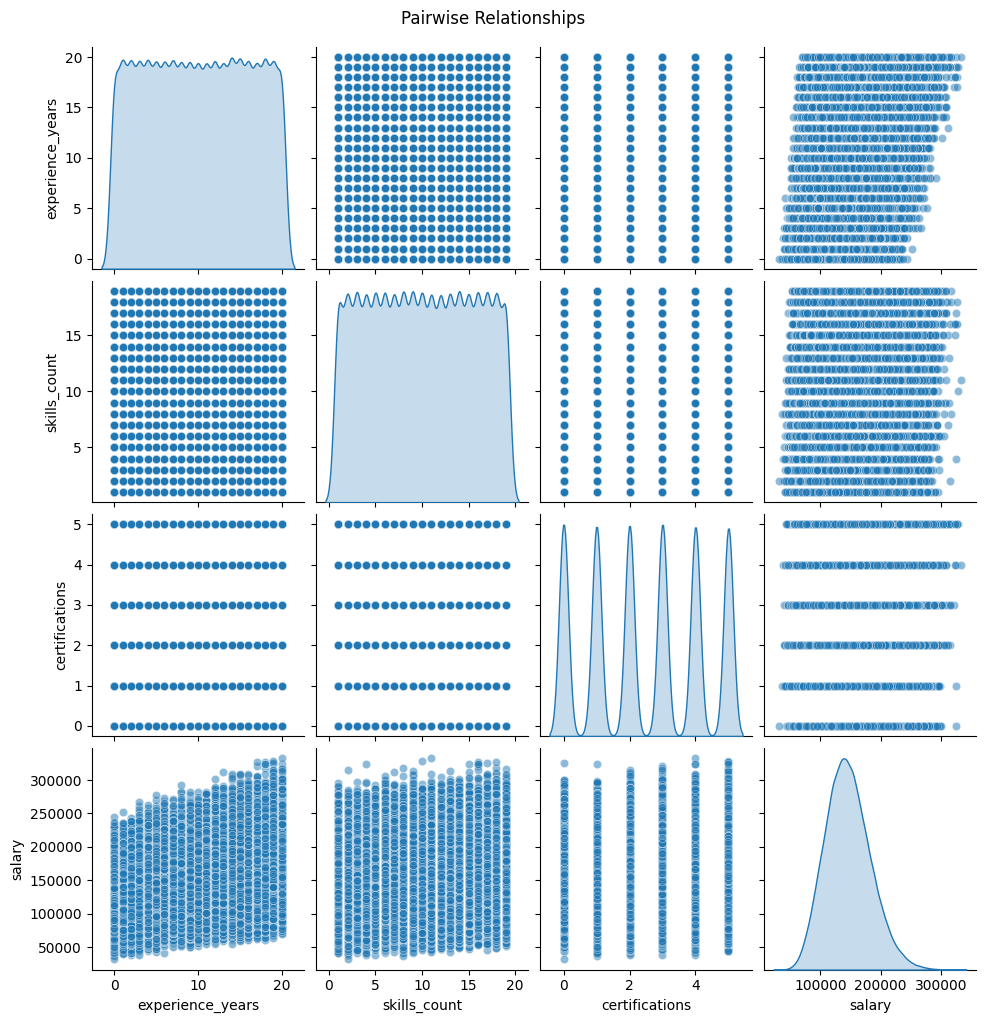

In [51]:
# Correlation matrix
numerical_cols = ['experience_years', 'skills_count', 'certifications', 'salary']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', linewidths=1)
plt.title('Correlation Matrix - Numerical Features')
plt.show()

# Pairplot
sns.pairplot(df[numerical_cols], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()


### 2.3 Interactive Visualizations

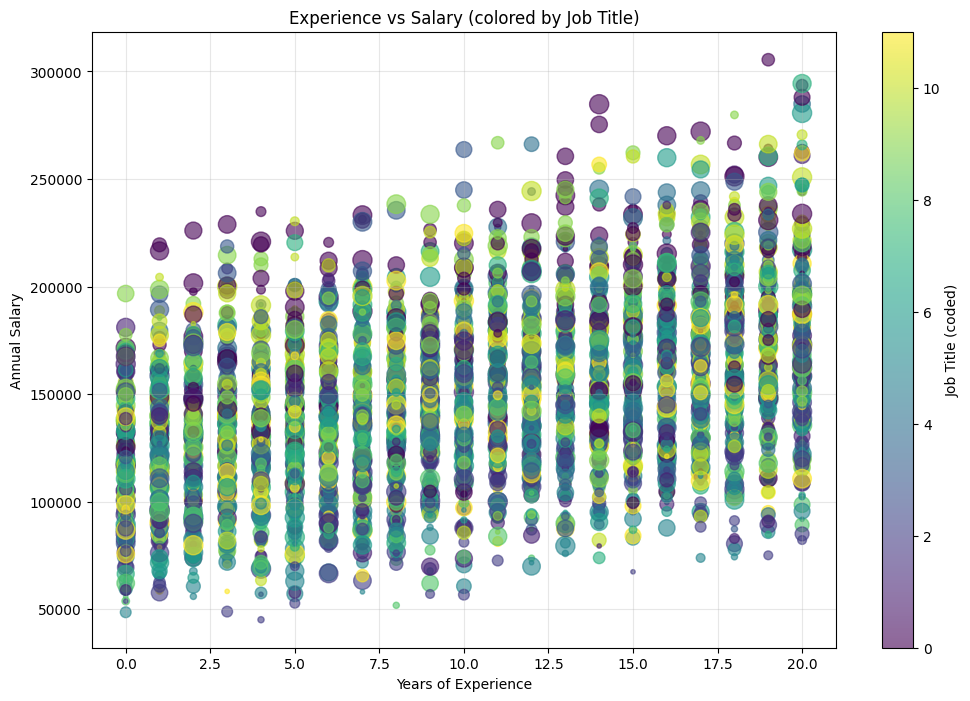

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample the data
sample_df = df.sample(5000)

# Create a scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(sample_df['experience_years'], 
                     sample_df['salary'],
                     c=pd.Categorical(sample_df['job_title']).codes,
                     s=sample_df['skills_count']*10,
                     alpha=0.6)

plt.xlabel('Years of Experience')
plt.ylabel('Annual Salary')
plt.title('Experience vs Salary (colored by Job Title)')
plt.colorbar(scatter, label='Job Title (coded)')
plt.grid(True, alpha=0.3)
plt.show()

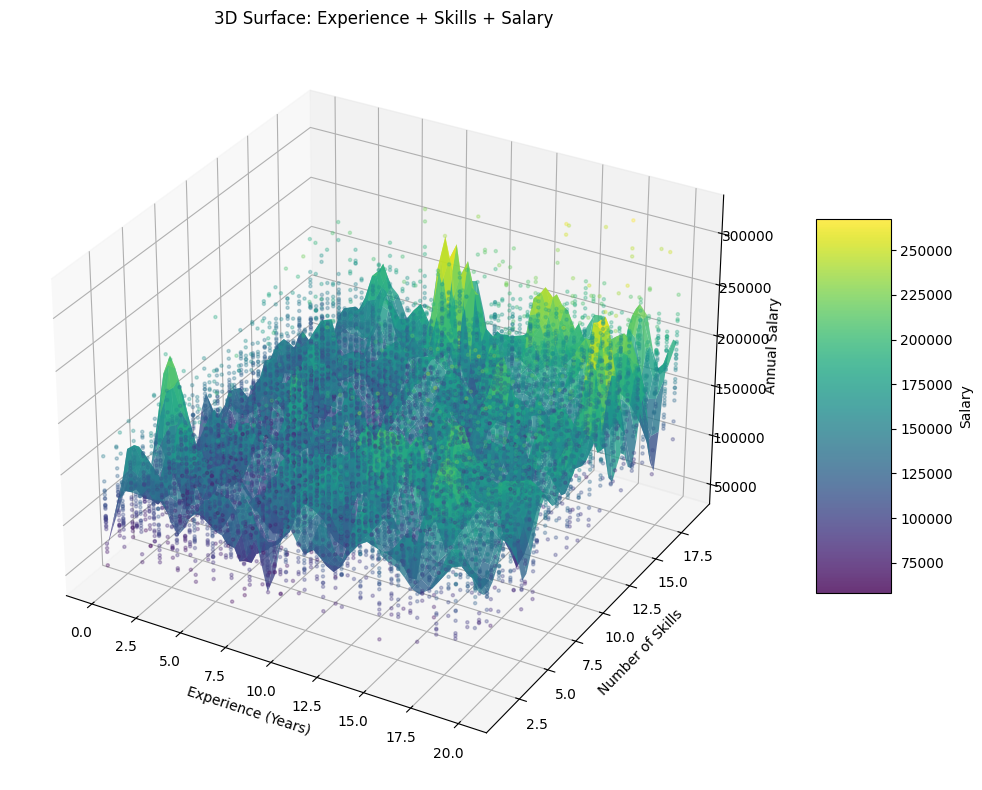

In [53]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import numpy as np

sample = df.sample(10000)

# Create grid
x = sample['experience_years']
y = sample['skills_count']
z = sample['salary']

# Create regular grid
xi = np.linspace(x.min(), x.max(), 50)
yi = np.linspace(y.min(), y.max(), 50)
xi, yi = np.meshgrid(xi, yi)

# Interpolate
zi = griddata((x, y), z, (xi, yi), method='cubic')

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
surf = ax.plot_surface(xi, yi, zi, cmap='viridis', alpha=0.8)

# Add scatter points on top
scatter = ax.scatter(x, y, z, c=z, cmap='viridis', alpha=0.3, s=5)

ax.set_xlabel('Experience (Years)')
ax.set_ylabel('Number of Skills')
ax.set_zlabel('Annual Salary')
ax.set_title('3D Surface: Experience + Skills + Salary')

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Salary')

plt.tight_layout()
plt.show()

# 3. Feature Engineering

In [54]:

df['experience_level'] = pd.cut(df['experience_years'], 
                                 bins=[0, 2, 5, 10, 50], 
                                 labels=['Junior', 'Mid', 'Senior', 'Expert'])

df['skill_density'] = df['skills_count'] / (df['experience_years'] + 1)
df['cert_per_year'] = df['certifications'] / (df['experience_years'] + 1)
df['total_qualifications'] = df['skills_count'] + df['certifications']

# Interaction features (
df['exp_x_skills'] = df['experience_years'] * df['skills_count']
df['exp_x_cert'] = df['experience_years'] * df['certifications']

# Premium features
df['is_tech'] = (df['industry'] == 'Tech').astype(int)
df['is_masters_plus'] = (df['education_level'].isin(["Master's", "PhD"])).astype(int)


print(df[['experience_level', 'skill_density', 'total_qualifications', 'is_tech']].head())


  experience_level  skill_density  total_qualifications  is_tech
0           Senior       0.181818                     4        0
1              Mid       2.833333                    17        0
2           Expert       0.210526                     5        0
3           Expert       0.650000                    13        0
4           Expert       0.437500                     7        0


# 4. Model Building

In [55]:
# Prepare data
X = df.drop(['salary', 'experience_level'], axis=1)  # experience_level is derived
y = df['salary']

# Identify columns
categorical_cols = ['job_title', 'education_level', 'industry', 'company_size', 
                    'location', 'remote_work']
numerical_cols = ['experience_years', 'skills_count', 'certifications', 
                  'skill_density', 'cert_per_year', 'total_qualifications', 
                  'exp_x_skills', 'exp_x_cert', 'is_tech', 'is_masters_plus']

# Preprocessor
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (200000, 16), Test size: (50000, 16)


In [56]:
X_test.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,skill_density,cert_per_year,total_qualifications,exp_x_skills,exp_x_cert,is_tech,is_masters_plus
38683,AI Engineer,11,Bachelor,7,Telecom,Startup,Canada,Hybrid,3,0.583333,0.250000,10,77,33,0,0
64939,DevOps Engineer,7,Master,14,Healthcare,Small,India,Hybrid,1,1.750000,0.125000,15,98,7,0,0
3954,Frontend Developer,10,Bachelor,2,Retail,Startup,India,Yes,5,0.181818,0.454545,7,20,50,0,0
120374,AI Engineer,8,Bachelor,9,Healthcare,Medium,Germany,No,4,1.000000,0.444444,13,72,32,0,0
172861,Software Engineer,2,Diploma,12,Retail,Large,Singapore,Hybrid,4,4.000000,1.333333,16,24,8,0,0


In [57]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Train and evaluate
results = []
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'CV R² (mean)': cv_scores.mean(),
        'CV R² (std)': cv_scores.std()
    })
    
    print(f"{name:20} | MAE: ${mae:,.0f} | RMSE: ${rmse:,.0f} | R²: {r2:.4f}")


Linear Regression    | MAE: $5,436 | RMSE: $7,126 | R²: 0.9635
Ridge Regression     | MAE: $5,436 | RMSE: $7,126 | R²: 0.9635
Lasso Regression     | MAE: $5,436 | RMSE: $7,126 | R²: 0.9635
Random Forest        | MAE: $5,003 | RMSE: $6,308 | R²: 0.9714
Gradient Boosting    | MAE: $6,320 | RMSE: $8,047 | R²: 0.9534
XGBoost              | MAE: $4,445 | RMSE: $5,578 | R²: 0.9776


In [58]:
# Results DataFrame
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
results_df


,Model,MAE,RMSE,R²,CV R² (mean),CV R² (std)
5,XGBoost,4445.194462,5577.944422,0.977614,0.977885,0.000217
3,Random Forest,5003.096029,6308.129610,0.971369,0.970491,0.000311
1,Ridge Regression,5436.289894,7125.731097,0.963467,0.963339,0.000203
2,Lasso Regression,5436.311125,7125.741158,0.963467,0.963339,0.000203
0,Linear Regression,5436.104740,7125.946676,0.963465,0.963335,0.000201
4,Gradient Boosting,6320.283084,8047.006525,0.953410,0.953572,0.000507


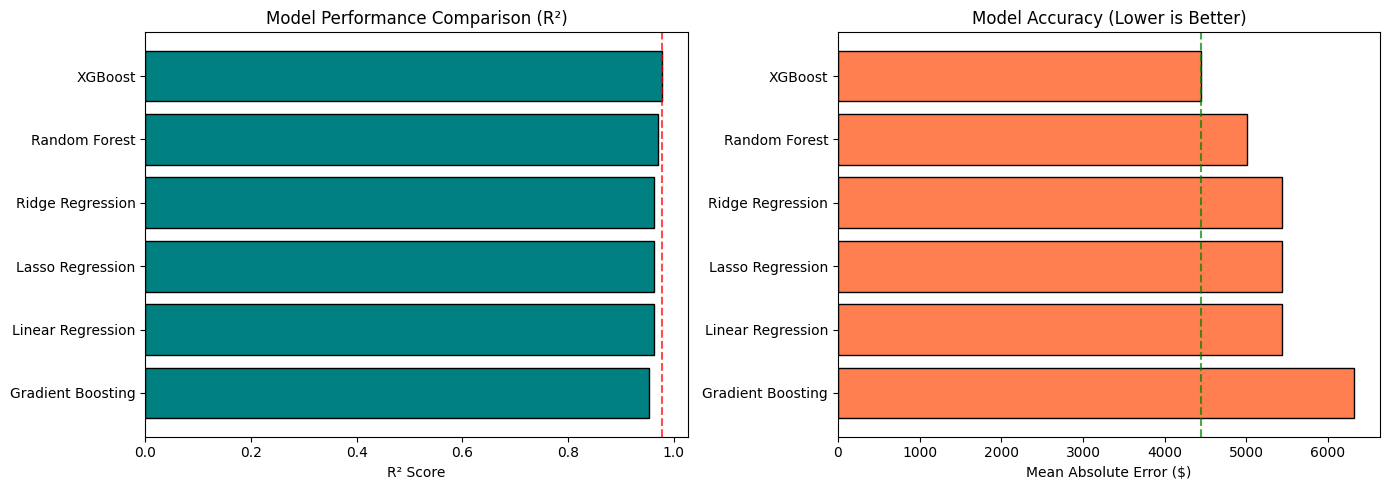

In [59]:
# Visualization of model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
bars = axes[0].barh(results_df['Model'], results_df['R²'], color='teal', edgecolor='black')
axes[0].axvline(results_df['R²'].max(), color='red', linestyle='--', alpha=0.7)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Performance Comparison (R²)')
axes[0].invert_yaxis()

# MAE comparison
bars = axes[1].barh(results_df['Model'], results_df['MAE'], color='coral', edgecolor='black')
axes[1].axvline(results_df['MAE'].min(), color='green', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Mean Absolute Error ($)')
axes[1].set_title('Model Accuracy (Lower is Better)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


# 5. Hyperparameter Tuning (Best Model)

In [60]:
# Tune XGBoost (our best performer)
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', XGBRegressor(random_state=42))])

param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [4, 6, 8],
    'regressor__learning_rate': [0.05, 0.1, 0.2],
    'regressor__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(xgb_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

# Final evaluation
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"\nFinal Test R²: {r2_score(y_test, y_pred_best):.4f}")
print(f"Final Test MAE: ${mean_absolute_error(y_test, y_pred_best):,.0f}")


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 6, 'regressor__n_estimators': 200, 'regressor__subsample': 1.0}
Best CV R²: 0.9801

Final Test R²: 0.9803
Final Test MAE: $4,181


# 6. Feature Importance Analysis

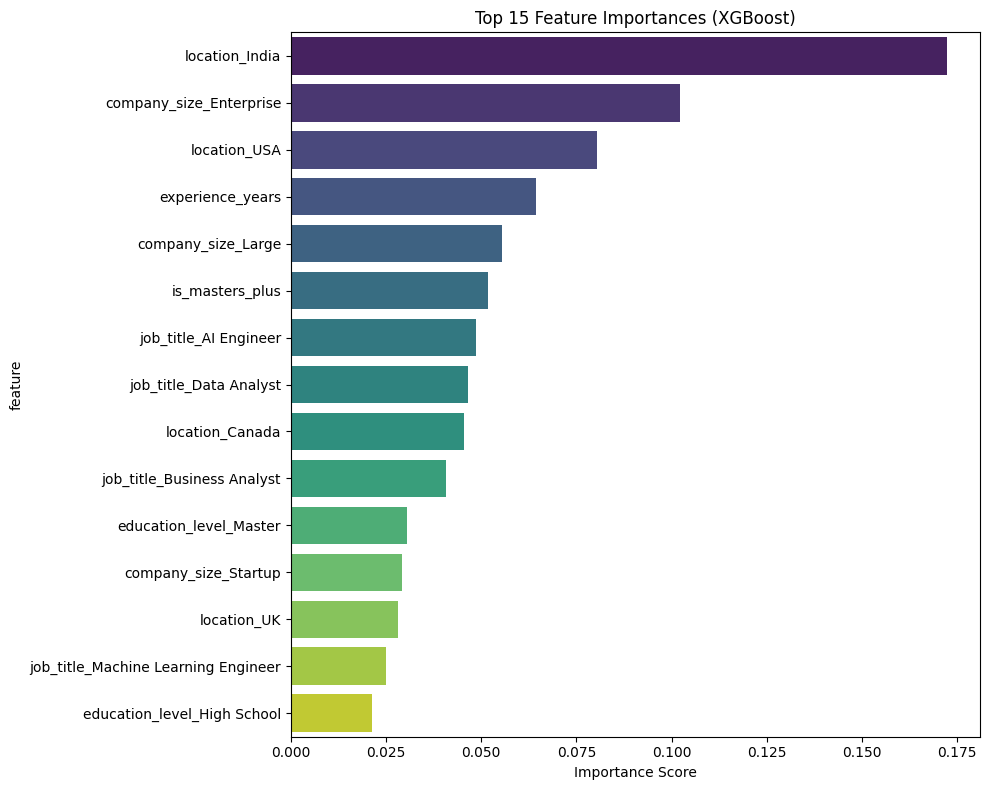

In [61]:
# Extract feature importance from best model
best_xgb = best_model.named_steps['regressor']
preprocessor_fitted = best_model.named_steps['preprocessor']

# Get feature names
cat_features = preprocessor_fitted.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_features = list(numerical_cols) + list(cat_features)

# Importance scores
importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), y='feature', x='importance', palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


# 7. Business Insights & Recommendations

In [62]:
# Salary uplift analysis
insights = {}

# Education premium
education_levels = ['Bachelor', 'PhD', 'High School', 'Diploma', 'Master']
for edu in education_levels:
    base = df[df['education_level'] == "Bachelor"]['salary'].mean()
    premium = df[df['education_level'] == edu]['salary'].mean() - base
    insights[f'Education: {edu} vs Bachelor\'s'] = f"${premium:+,.0f}"

# Certification impact
cert_effect = df.groupby('certifications')['salary'].mean().diff().mean()
insights['Per additional certification'] = f"${cert_effect:,.0f}"

# Skill premium
skill_effect = df.groupby('skills_count')['salary'].mean().diff().mean()
insights['Per additional skill'] = f"${skill_effect:,.0f}"

# Experience ROI
exp_10_vs_0 = df[df['experience_years'] >= 10]['salary'].mean() - df[df['experience_years'] < 2]['salary'].mean()
insights['10+ years vs <2 years'] = f"${exp_10_vs_0:,.0f}"

# Remote work impact
remote_effect = df[df['remote_work'] == 'Full Remote']['salary'].mean() - df[df['remote_work'] == 'On-site']['salary'].mean()
insights['Full Remote vs On-site'] = f"${remote_effect:+,.0f}"

# Display insights
print("="*60)
print("KEY SALARY INSIGHTS")
print("="*60)
for k, v in insights.items():
    print(f"{k:35} : {v}")


KEY SALARY INSIGHTS
Education: Bachelor vs Bachelor's   : $+0
Education: PhD vs Bachelor's        : $+21,565
Education: High School vs Bachelor's : $-10,695
Education: Diploma vs Bachelor's    : $-5,252
Education: Master vs Bachelor's     : $+10,895
Per additional certification        : $1,623
Per additional skill                : $854
10+ years vs <2 years               : $39,157
Full Remote vs On-site              : $+nan


# 8. Prediction Function (Deployment Ready)

In [63]:
def predict_salary(model, preprocessor, job_title, experience_years, education_level, 
                   skills_count, industry, company_size, location, remote_work, certifications):
    """
    Predict salary for a given job profile.
    
    Returns: Predicted annual salary (float)
    """
    input_data = pd.DataFrame([{
        'job_title': job_title,
        'experience_years': experience_years,
        'education_level': education_level,
        'skills_count': skills_count,
        'industry': industry,
        'company_size': company_size,
        'location': location,
        'remote_work': remote_work,
        'certifications': certifications
    }])
    
    # Add engineered features (same as training)
    input_data['skill_density'] = input_data['skills_count'] / (input_data['experience_years'] + 1)
    input_data['cert_per_year'] = input_data['certifications'] / (input_data['experience_years'] + 1)
    input_data['total_qualifications'] = input_data['skills_count'] + input_data['certifications']
    input_data['exp_x_skills'] = input_data['experience_years'] * input_data['skills_count']
    input_data['exp_x_cert'] = input_data['experience_years'] * input_data['certifications']
    input_data['is_tech'] = (input_data['industry'] == 'Tech').astype(int)
    input_data['is_masters_plus'] = (input_data['education_level'].isin(["Master's", "PhD"])).astype(int)
    
    prediction = model.predict(input_data)[0]
    return prediction

# Example usage
example_pred = predict_salary(
    model=best_model,
    preprocessor=preprocessor,
    job_title='AI Engineer',
    experience_years=5,
    education_level="Master's",
    skills_count=12,
    industry='Tech',
    company_size='Large (500+)',
    location='San Francisco',
    remote_work='Hybrid',
    certifications=3
)
print(f"Predicted Salary for AI Engineer (5 yrs, Master's, SF): ${example_pred:,.0f}")


Predicted Salary for AI Engineer (5 yrs, Master's, SF): $168,067


# 9. Save Model 

In [64]:
import joblib

# Save best model and preprocessor
joblib.dump(best_model, 'salary_predictor_model.pkl')
print("Model saved as 'salary_predictor_model.pkl'")

Model saved as 'salary_predictor_model.pkl'
